In [23]:
from spin_lattices import KagomeLattice, SpinLattice, ChainLattice
from sympy.combinatorics import Permutation, PermutationGroup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from igraph import Graph

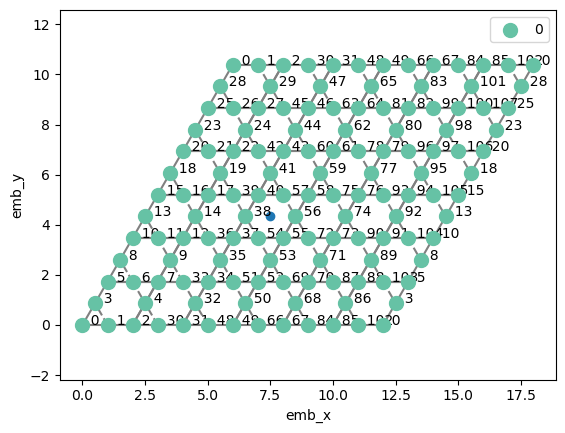

In [9]:
lat = KagomeLattice(6, 6)
u, v = lat.lattice_basis.T
lat.plot()
hexagonal_center = lat.sites_df[['emb_x', 'emb_y']].mean().to_numpy() - u - v
plt.plot(*hexagonal_center, 'o')

In [10]:
df = lat.sites_df.assign(
    distance_to_center=lambda df: df[["emb_x", "emb_y"]]
    .sub(df[["emb_x", "emb_y"]].mean(axis=0), axis=1)
    .pow(2)
    .sum(axis=1)
    .pow(0.5)
).sort_values("distance_to_center").reset_index(drop=True)

In [23]:
df.head(50)

,num,ix,iy,is_canonical,emb_x,emb_y,distance_to_center
0,35,4,6,True,7.0,5.196152,1.000000
1,49,5,6,True,8.0,5.196152,1.000000
2,33,4,5,True,6.5,4.330127,1.000000
3,48,6,5,True,8.5,4.330127,1.000000
4,46,5,4,True,7.0,3.464102,1.000000
5,47,6,4,True,8.0,3.464102,1.000000
6,34,3,6,True,6.0,5.196152,1.732051
7,36,4,7,True,7.5,6.062178,1.732051
8,50,6,6,True,9.0,5.196152,1.732051
9,32,4,4,True,6.0,3.464102,1.732051


In [16]:
lat.sites_df

,num,ix,iy,is_canonical,emb_x,emb_y
0,0,0,0,True,0.0,0.000000
1,1,1,0,True,1.0,0.000000
2,2,2,0,True,2.0,0.000000
3,3,0,1,True,0.5,0.866025
4,4,2,1,True,2.5,0.866025
...,...,...,...,...,...,...
91,74,9,8,True,13.0,6.928203
92,20,10,8,False,14.0,6.928203
93,23,10,9,False,14.5,7.794229
94,70,9,10,False,14.0,8.660254


In [20]:
df.assign(
    selected=lambda df: df["distance_to_center"] < df["distance_to_center"].iloc[45] - 1e-5
).query("num == 16")

,num,ix,iy,is_canonical,emb_x,emb_y,distance_to_center,selected
33,16,1,6,True,4.0,5.196152,3.605551,True


In [25]:
lat.edges_to_kind

{(0, 1): 1,
 (1, 2): 1,
 (0, 3): 1,
 (1, 3): 2,
 (3, 5): 1,
 (5, 6): 1,
 (6, 4): 2,
 (6, 7): 1,
 (4, 7): 1,
 (2, 4): 1,
 (5, 8): 1,
 (6, 8): 2,
 (8, 10): 1,
 (10, 11): 1,
 (11, 9): 2,
 (11, 12): 1,
 (9, 12): 1,
 (7, 9): 1,
 (10, 13): 1,
 (11, 13): 2,
 (13, 15): 1,
 (15, 16): 1,
 (16, 14): 2,
 (16, 17): 1,
 (14, 17): 1,
 (12, 14): 1,
 (15, 18): 1,
 (16, 18): 2,
 (18, 20): 1,
 (20, 21): 1,
 (21, 19): 2,
 (21, 22): 1,
 (19, 22): 1,
 (17, 19): 1,
 (20, 23): 1,
 (21, 23): 2,
 (23, 0): 1,
 (1, 24): 2,
 (24, 2): 1,
 (22, 24): 1,
 (2, 25): 1,
 (25, 26): 1,
 (25, 4): 2,
 (7, 28): 1,
 (28, 27): 2,
 (28, 29): 1,
 (27, 29): 1,
 (26, 27): 1,
 (28, 9): 2,
 (12, 31): 1,
 (31, 30): 2,
 (31, 32): 1,
 (30, 32): 1,
 (29, 30): 1,
 (31, 14): 2,
 (17, 34): 1,
 (34, 33): 2,
 (34, 35): 1,
 (33, 35): 1,
 (32, 33): 1,
 (34, 19): 2,
 (22, 37): 1,
 (37, 36): 2,
 (37, 38): 1,
 (36, 38): 1,
 (35, 36): 1,
 (37, 24): 2,
 (25, 39): 2,
 (39, 26): 1,
 (38, 39): 1,
 (26, 40): 1,
 (40, 41): 1,
 (40, 27): 2,
 (29, 43): 1,


In [26]:
def get_adjacent_sites(site: int, edges_to_kind: dict[tuple[int, int], int]) -> list[int]:
    adjacent_sites = []
    for edge in edges_to_kind:
        if site == edge[0]:
            adjacent_sites.append(edge[1])
        elif site == edge[1]:
            adjacent_sites.append(edge[0])
    return adjacent_sites

In [39]:
def dilatate(lattice, sites_mask, n=1):
    assert n >= 0
    if n == 0:
        return sites_mask
    dilatated_mask = sites_mask.copy()
    for site_num in range(lattice.number_spins):
        if sites_mask[get_adjacent_sites(site_num, lattice.edges_to_kind)].any():
            dilatated_mask[site_num] = 1
    return dilatate(lattice, dilatated_mask, n=n-1)

In [33]:
hexagon_nums = df.head(6)["num"].to_numpy()
hexagon_mask = np.isin(np.arange(lat.number_spins), hexagon_nums)

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

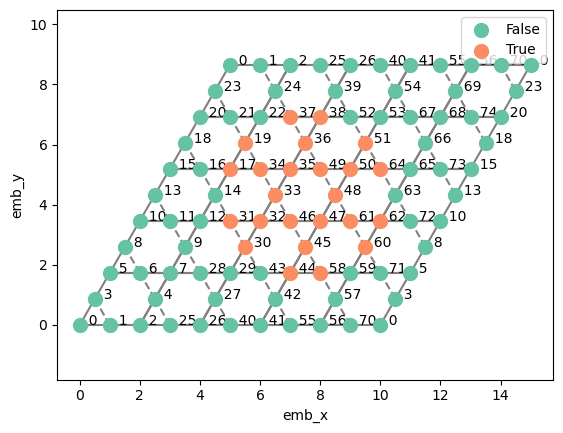

In [42]:
lat.plot(spins=dilatate(lat, hexagon_mask, 2))

In [18]:
lat.as_igraph().get_adjlist()[0]

[1, 3, 28, 102]

In [20]:
from sympy.combinatorics import Permutation, PermutationGroup
from igraph import Graph

def factor_lattice(
    graph: Graph, generators: list[list], fundamental_domain: list[int]
) -> Graph:
    # Create an empty graph with vertices corresponding to the fundamental_domain
    factor_graph = Graph()
    factor_graph.add_vertices(map(str, fundamental_domain))

    # Generate a permutation group from the provided generators
    group = PermutationGroup(map(Permutation, generators))

    # For each pair of vertices a and b in fundamental_domain
    for a in fundamental_domain:
        for b in fundamental_domain:
            # If there exists a permutation g in group such that a and g(b) are connected by an edge in the original graph
            for g in group:
                gb = g(b)
                if graph.are_connected(a, gb):
                    # Check if the edge already exists in the factor_graph
                    if factor_graph.get_eid(a, b, error=False) == -1:
                        # If not, then add an edge between a and b in factor_graph, preserving the edge attribute 'kind' from the original graph
                        edge_id = graph.get_eid(a, gb)
                        kind = graph.es[edge_id]['kind']
                        factor_graph.add_edge(a, b, kind=kind)
                    
    return factor_graph


In [24]:
lat = ChainLattice(8)
lat.get_translation('x')

[1, 2, 3, 4, 5, 6, 7, 0]